# Exploratory Data Analysis

This notebook performs an exploratory data analysis of the course dataset stored in `dataset.csv`.
The original API-based extraction code is kept commented for reference, but all current analyses use the local CSV file.
Competency names are translated to English for analysis and visualization, while the raw Portuguese labels remain available in the dataset.


In [73]:
import os, requests

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# from dotenv import load_dotenv
import networkx as nx
from matplotlib.patches import Arc
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from itertools import combinations

# load_dotenv()


## Data Source

The next cells preserve the original API request workflow as commented code.
They are intentionally disabled because the notebook now reads directly from `dataset.csv`.


In [ ]:
courses_url = "https://api.plaforedu.cluster.prd.app.rnp.br/courses/all"

params = {
    "includeFiled": False,
    "onlyPending": False,
    "registerLog": False,
    "orderByCreated": False,
    "orderByUpdated": False,
}

headers = {
    "accept": "application/json",
    "Content-Type": "application/json",
    "Cookie": f"id={os.getenv('COOCKIE_ID')}",
}

data = {
    "search": "",
    "hours": [],
    "institutions": [],
    "accessibilities": [],
    "itineraries": [],
    "competencies": [],
    "subThemes": [],
    "taxonomies": [],
}

response = requests.post(courses_url, headers=headers, params=params, json=data)

len(response.json()["data"])


In [ ]:
all_competencies = []
all_categories = []

for curso in response.json()["data"]:
    competencies_list = curso.get("competencies", [])

    if not competencies_list:
        continue

    for comp in competencies_list:
        if comp.get("name"):
            all_competencies.append(comp["name"])

        categories_list = comp.get("categories", [])

        if not categories_list:
            continue

        for cat in categories_list:
            if cat.get("name"):
                all_categories.append(cat["name"])


In [ ]:
df_competencies_freq = pd.Series(all_competencies).value_counts().reset_index()
df_competencies_freq.columns = ["competencia", "frequencia"]

df_categories_freq = pd.Series(all_categories).value_counts().reset_index()
df_categories_freq.columns = ["categoria", "frequencia"]


## Data Preparation

This section loads the CSV dataset, translates competency names into English, and builds deduplicated tables for competency- and category-level analysis.
The deduplication step avoids inflating counts when the same competency appears multiple times for the same course because of taxonomy labels.


In [77]:
competency_translation = {'Abertura ao Novo': 'Openness to New Experiences', 'Acessibilidade e inclusão - Docente': 'Accessibility and Inclusion - Educator', 'Análise de evidências': 'Evidence Analysis', 'Análise de problemas': 'Problem Analysis', 'Aprendizado Contínuo': 'Continuous Learning', 'Aprendizagem autorregulada': 'Self-Regulated Learning', 'Aprendizagem colaborativa': 'Collaborative Learning', 'Autoconhecimento e desenvolvimento pessoal': 'Self-Knowledge and Personal Development', 'Autogestão': 'Self-Management', 'Colaboração profissional': 'Professional Collaboration', 'Comunicação': 'Communication', 'Comunicação e colaboração digital': 'Digital Communication and Collaboration', 'Comunicação efetiva': 'Effective Communication', 'Comunicação institucional': 'Institutional Communication', 'Comunicação interpessoal': 'Interpersonal Communication', 'Construção de Redes': 'Network Building', 'Contribuição técnico-profissional': 'Technical-Professional Contribution', 'Controle emocional': 'Emotional Control', 'Criatividade': 'Creativity', 'Criação de conteúdo digital': 'Digital Content Creation', 'Criação e modificação': 'Creation and Modification', 'Desenvolvimento Profissional Contínuo (DPC) digital': 'Digital Continuing Professional Development (CPD)', 'Diferenciação e personalização': 'Differentiation and Personalization', 'Ensino': 'Teaching', 'Envolvimento ativo': 'Active Engagement', 'Estratégias de avaliação': 'Assessment Strategies', 'Feedback e planificação': 'Feedback and Planning', 'Foco nos resultados para os cidadãos': 'Focus on Results for Citizens', 'Geração de valor para o usuario': 'Value Generation for the User', 'Gerenciamento da mudança': 'Change Management', 'Gerenciamento de políticas': 'Policy Management', 'Gerenciamento de recursos': 'Resource Management', 'Gerenciamento digital': 'Digital Management', 'Gestão da participação cidadã': 'Citizen Participation Management', 'Gestão da qualidade': 'Quality Management', 'Gestão do desenvolvimento de pessoas': 'People Development Management', 'Gestão do trabalho em equipe': 'Teamwork Management', 'Gestão para resultados': 'Management for Results', 'Gestão, proteção e compartilhamento': 'Management, Protection, and Sharing', 'Inovação': 'Innovation', 'Liderança eficaz': 'Effective Leadership', 'Literacia da informação e das mídias': 'Information and Media Literacy', 'Melhoria contínua de processos': 'Continuous Process Improvement', 'Mentalidade Digital': 'Digital Mindset', 'Negociação': 'Negotiation', 'Não especificado': 'Unspecified', 'Organização da rotina': 'Routine Organization', 'Orientação': 'Guidance', 'Orientação ao cidadão': 'Citizen Orientation', 'Orientações por valores éticos': 'Ethical Values Guidance', 'Planejamento': 'Planning', 'Proatividade': 'Proactivity', 'Promoção da Inclusão e Acessibilidade': 'Promotion of Inclusion and Accessibility', 'Prática reflexiva': 'Reflective Practice', 'Relacionamento com dirigentes': 'Relationship with Leaders', 'Relações institucionais': 'Institutional Relations', 'Resolução de problemas com base em dados': 'Data-Driven Problem Solving', 'Resolução de problemas digitais': 'Digital Problem Solving', 'Seleção': 'Selection', 'Tomada de decisão': 'Decision-Making', 'Tomada de decisão para gestores': 'Decision-Making for Managers', 'Trabalho em equipe': 'Teamwork', 'Uso de TIC': 'ICT Use', 'Uso responsável': 'Responsible Use', 'Visão Sistêmica': 'Systems Thinking', 'Visão de Futuro': 'Future Vision', 'Visão estratégica': 'Strategic Vision'}

df = pd.read_csv("dataset.csv")
df["competency_en"] = df["comp_name"].map(competency_translation).fillna(df["comp_name"])
category_translation = {'Avaliação': 'Assessment', 'Capacitação dos(as) Estudantes': 'Student Empowerment', 'Categoria de Competências 01': 'Competency Category 01', 'Competência de Liderança - Estratégia': 'Leadership Competency - Strategy', 'Competências de Liderança - Pessoas': 'Leadership Competencies - People', 'Competências de Liderança - Resultados': 'Leadership Competencies - Results', 'Ensino e Aprendizagem': 'Teaching and Learning', 'Envolvimento Profissional': 'Professional Engagement', 'Gestão de Mudanças': 'Change Management', 'Gestão de Relacionamentos': 'Relationship Management', 'Gestão de Resultados': 'Results Management', 'Não especificado': 'Unspecified', 'Orientação a Resultados': 'Results Orientation', 'Processos de Melhoria': 'Improvement Processes', 'Promoção da Competência Digital dos(as) Estudantes': "Fostering Students' Digital Competence", 'Recursos Digitais': 'Digital Resources', 'Transversais': 'Transversal'}
df["category_en"] = df["cat_name"].map(category_translation).fillna(df["cat_name"])

course_competencies = (
    df[["courseId", "courseName", "comp_id", "comp_name", "competency_en"]]
    .dropna(subset=["comp_id", "comp_name"])
    .drop_duplicates()
)

course_categories = (
    df[["courseId", "courseName", "cat_id", "cat_name", "category_en"]]
    .dropna(subset=["cat_id", "cat_name"])
    .drop_duplicates()
)

df_competencies_freq = (
    course_competencies["competency_en"]
    .value_counts()
    .rename_axis("competency")
    .reset_index(name="frequency")
)

df_categories_freq = (
    course_categories[["cat_name", "category_en"]]
    .drop_duplicates()
    .merge(
        course_categories["cat_name"].value_counts().rename("frequency"),
        left_on="cat_name",
        right_index=True
    )
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

df.head()


,courseId,courseName,courseDescription,courseHours,comp_id,comp_name,comp_description,cat_id,cat_name,tax_id,tax_name,competency_en,category_en
0,c3dc5a27-f76b-46a3-b9c9-644d35a66baf,A arte de falar em público,"Neste curso, você terá a oportunidade de conhe...",20,6461c25c-1491-4610-8ee0-2029d77fa61d,Comunicação e colaboração digital,"Incorporar atividades, tarefas e avaliações de...",05ac4a5c-019d-4ec7-83cc-12ca141322fa,Promoção da Competência Digital dos(as) Estuda...,85f646ca-67c5-439c-8cc1-df4fed9e0ae7,Lembrar,Digital Communication and Collaboration,Fostering Students' Digital Competence
1,c3dc5a27-f76b-46a3-b9c9-644d35a66baf,A arte de falar em público,"Neste curso, você terá a oportunidade de conhe...",20,6461c25c-1491-4610-8ee0-2029d77fa61d,Comunicação e colaboração digital,"Incorporar atividades, tarefas e avaliações de...",05ac4a5c-019d-4ec7-83cc-12ca141322fa,Promoção da Competência Digital dos(as) Estuda...,6152c8bb-1632-42f0-9599-919b6bf15ecb,Entender,Digital Communication and Collaboration,Fostering Students' Digital Competence
2,c3dc5a27-f76b-46a3-b9c9-644d35a66baf,A arte de falar em público,"Neste curso, você terá a oportunidade de conhe...",20,6461c25c-1491-4610-8ee0-2029d77fa61d,Comunicação e colaboração digital,"Incorporar atividades, tarefas e avaliações de...",05ac4a5c-019d-4ec7-83cc-12ca141322fa,Promoção da Competência Digital dos(as) Estuda...,7b16819f-cb8a-406d-9ab9-a335a50143cb,Aplicar,Digital Communication and Collaboration,Fostering Students' Digital Competence
3,c3dc5a27-f76b-46a3-b9c9-644d35a66baf,A arte de falar em público,"Neste curso, você terá a oportunidade de conhe...",20,cdbece75-961d-4176-b34b-66e1a530dcf2,Comunicação institucional,Usar tecnologias digitais para melhorar a comu...,690c731c-31f8-46f6-94f6-94d952223a08,Envolvimento Profissional,85f646ca-67c5-439c-8cc1-df4fed9e0ae7,Lembrar,Institutional Communication,Professional Engagement
4,c3dc5a27-f76b-46a3-b9c9-644d35a66baf,A arte de falar em público,"Neste curso, você terá a oportunidade de conhe...",20,cdbece75-961d-4176-b34b-66e1a530dcf2,Comunicação institucional,Usar tecnologias digitais para melhorar a comu...,690c731c-31f8-46f6-94f6-94d952223a08,Envolvimento Profissional,6152c8bb-1632-42f0-9599-919b6bf15ecb,Entender,Institutional Communication,Professional Engagement


## Competency Frequency

The following chart shows how often each translated competency appears across courses.
Competency labels are displayed in English, while titles and axis labels are bilingual for presentation purposes.


/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_14208/3397310466.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


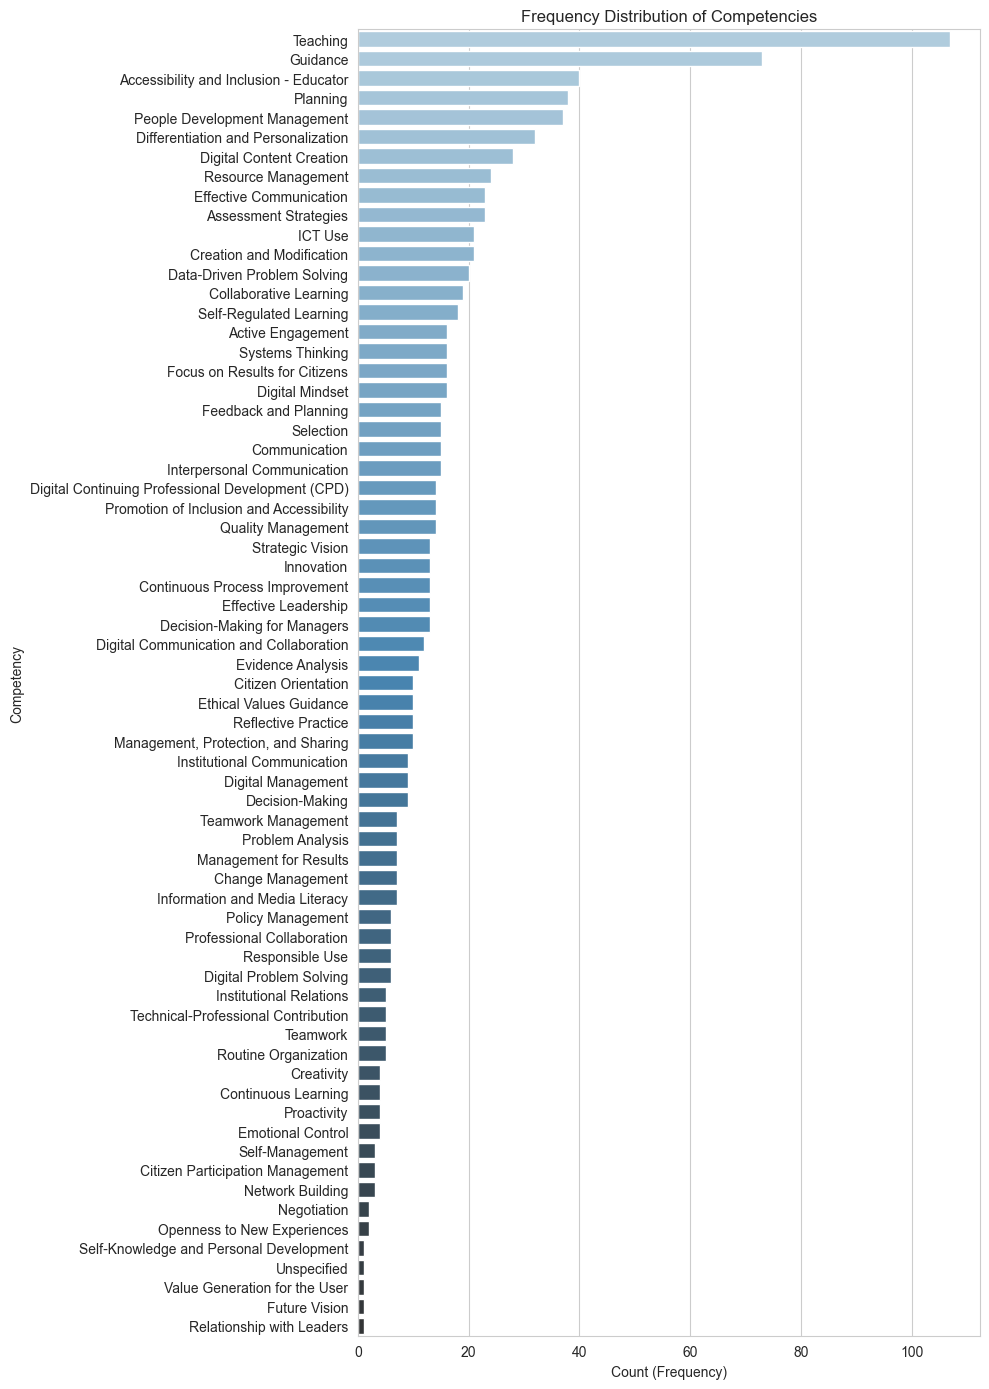

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_14208/3397310466.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


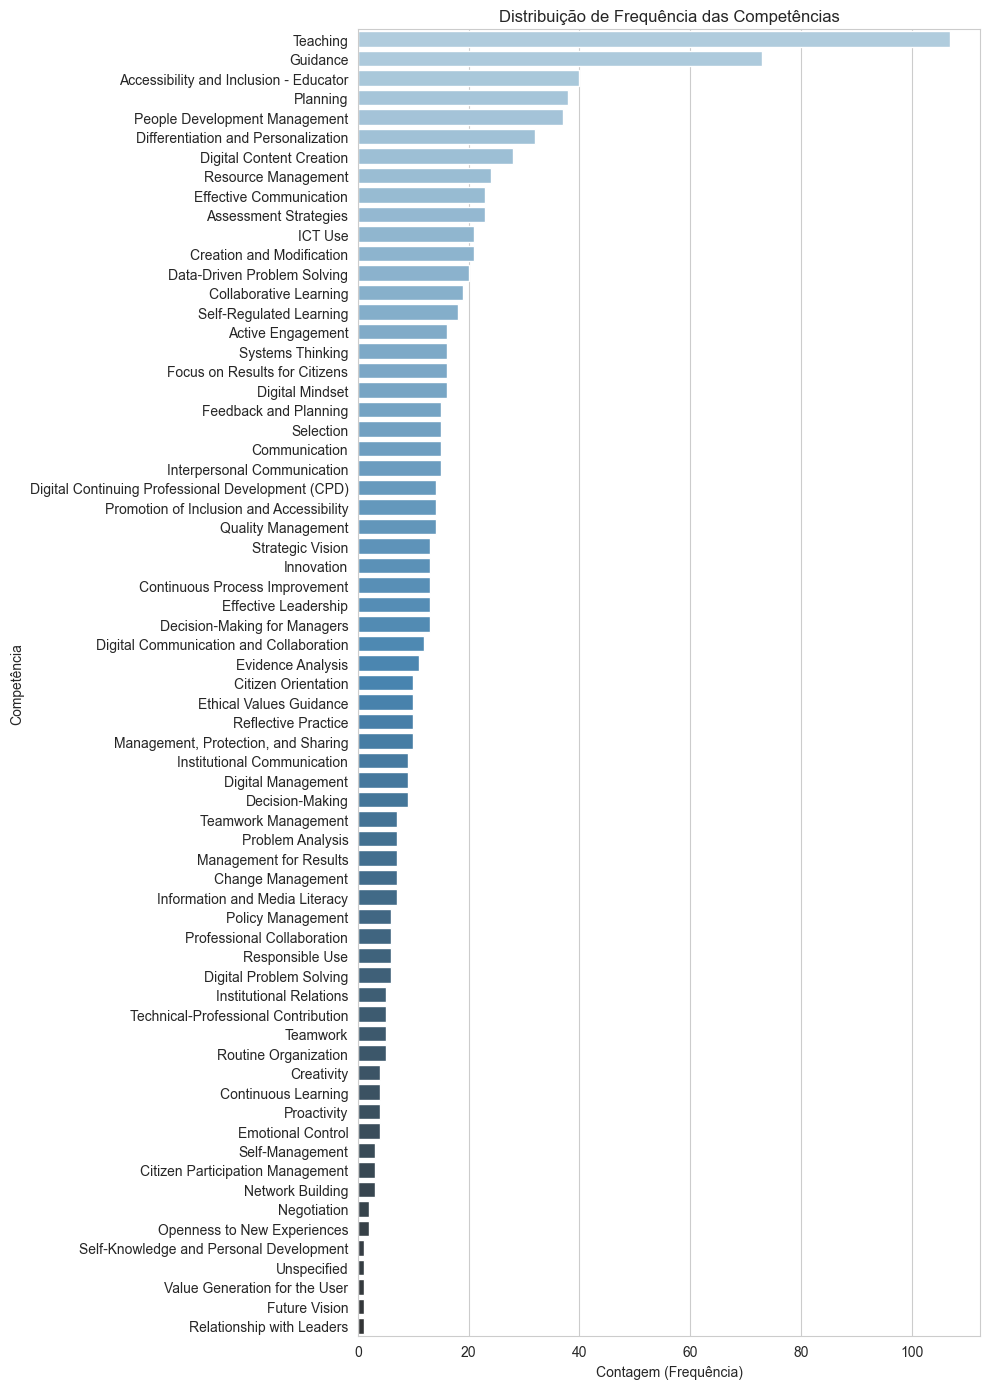

In [78]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 14))
sns.barplot(
    data=df_competencies_freq,
    x="frequency",
    y="competency",
    palette="Blues_d"
)
plt.title("Frequency Distribution of Competencies")
plt.xlabel("Count (Frequency)")
plt.ylabel("Competency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 14))
sns.barplot(
    data=df_competencies_freq,
    x="frequency",
    y="competency",
    palette="Blues_d"
)
plt.title("Distribuição de Frequência das Competências")
plt.xlabel("Contagem (Frequência)")
plt.ylabel("Competência")
plt.tight_layout()
plt.show()


In [79]:
df_competencies_freq.describe(include="all")


,competency,frequency
count,67,67.000000
unique,67,NaN
top,Teaching,NaN
freq,1,NaN
mean,NaN,14.298507
std,NaN,16.404004
min,NaN,1.000000
25%,NaN,5.000000
50%,NaN,10.000000
75%,NaN,16.000000


## Competency Co-occurrence

This section computes competency pairs that appear together within the same course.
It helps identify common competency combinations and the strongest associations in the catalog.


In [80]:
all_pairs = []

for _, group in course_competencies.groupby("courseId"):
    comp_names = sorted(group["competency_en"].unique())

    if len(comp_names) < 2:
        continue

    all_pairs.extend(combinations(comp_names, 2))


In [81]:
s_pairs_freq = pd.Series(all_pairs).value_counts()

df_pairs_freq = s_pairs_freq.reset_index()
df_pairs_freq.columns = ["competency_pair", "frequency"]

df_pairs_freq


,competency_pair,frequency
0,"(Guidance, Teaching)",71
1,"(Accessibility and Inclusion - Educator, Diffe...",26
2,"(Creation and Modification, Digital Content Cr...",16
3,"(Collaborative Learning, Teaching)",15
4,"(Assessment Strategies, Feedback and Planning)",14
...,...,...
712,"(Policy Management, Routine Organization)",1
713,"(Interpersonal Communication, Self-Knowledge a...",1
714,"(Emotional Control, Self-Knowledge and Persona...",1
715,"(Policy Management, Strategic Vision)",1


In [82]:
df_pairs_freq.iloc[0]["frequency"] / df_pairs_freq["frequency"].sum()


np.float64(0.04303030303030303)

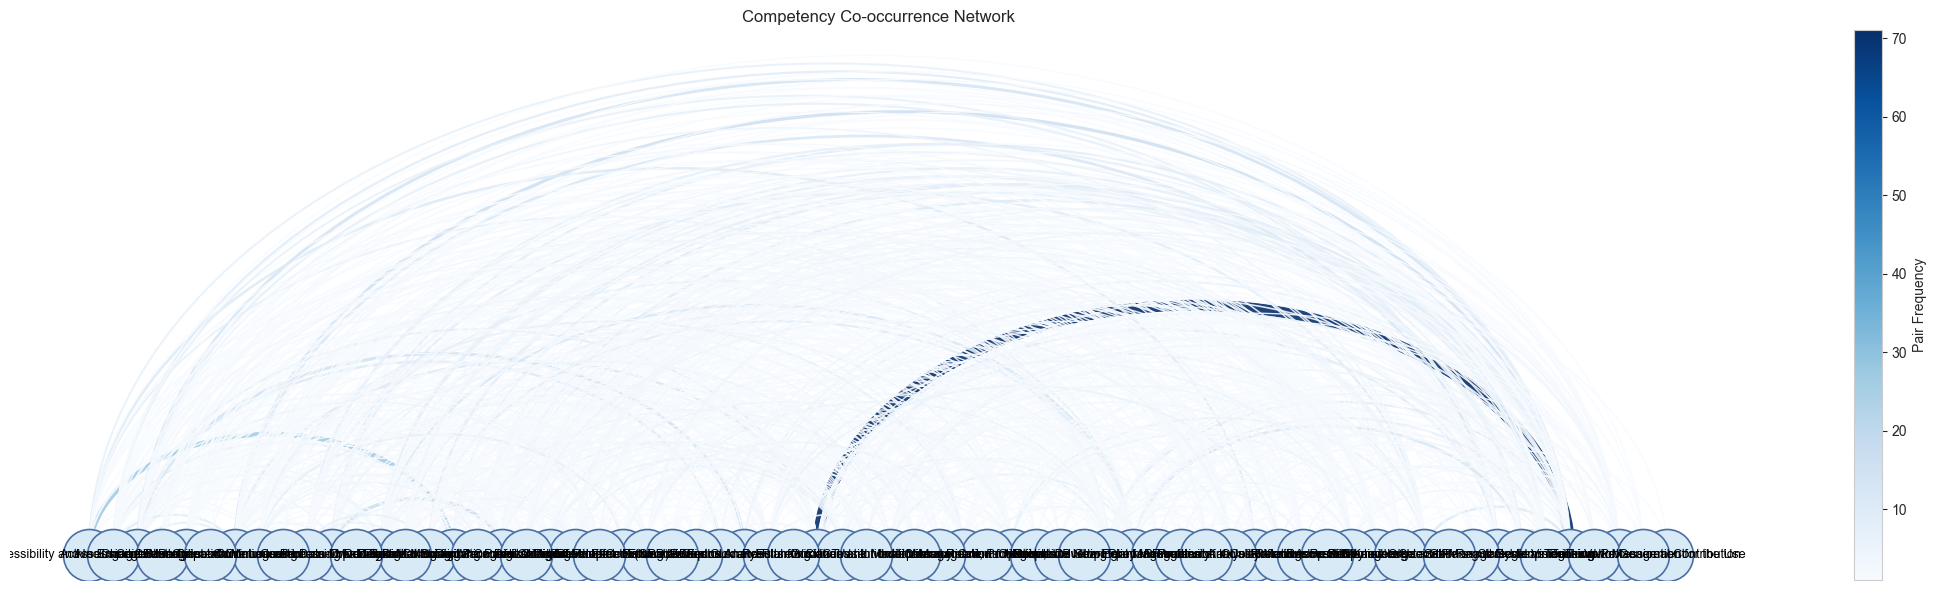

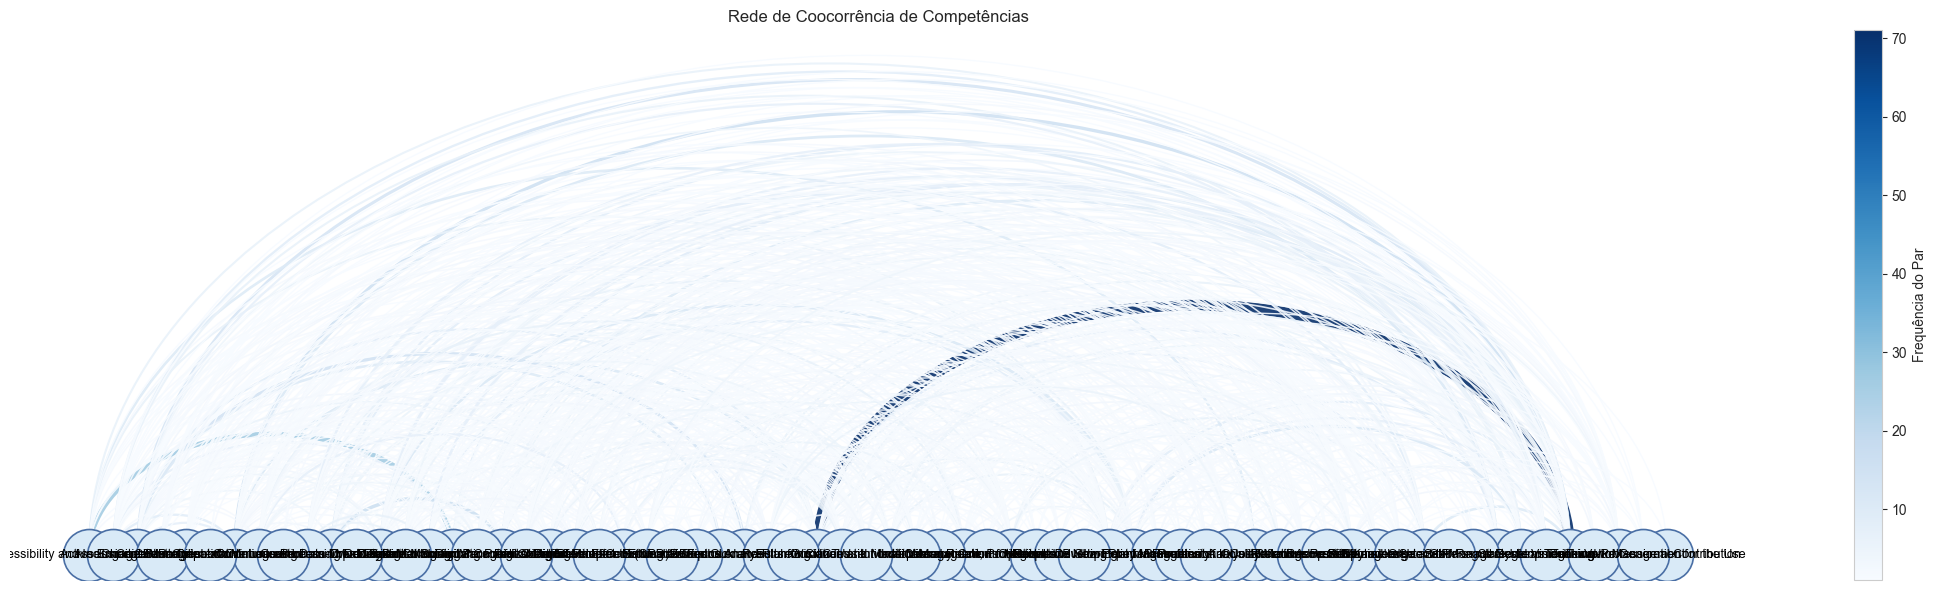

In [83]:
df_edges = df_pairs_freq.copy()
df_edges[["source", "target"]] = pd.DataFrame(
    df_edges["competency_pair"].tolist(),
    index=df_edges.index
)
df_edges = df_edges.rename(columns={"frequency": "weight"})

G = nx.from_pandas_edgelist(
    df_edges,
    source="source",
    target="target",
    edge_attr="weight"
)

nodes = sorted(G.nodes())
pos = {node: (i, 0) for i, node in enumerate(nodes)}

weights = [G[u][v]["weight"] for u, v in G.edges()]

if not weights:
    print("No pairs found to draw.")
    print("Nenhum par encontrado para plotar.")
else:
    min_weight = min(weights)
    max_weight = max(weights)

    if max_weight == min_weight:
        norm_weights = [3] * len(weights)
    else:
        norm_weights = [
            1 + 7 * ((w - min_weight) / (max_weight - min_weight))
            for w in weights
        ]

    norm = mcolors.Normalize(vmin=min_weight, vmax=max_weight)
    cmap = cm.Blues

    plt.figure(figsize=(22, 6))
    ax = plt.gca()

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1400,
        node_color="#d9eaf7",
        edgecolors="#4a6fa5",
        linewidths=1.2,
        ax=ax
    )

    for (u, v), weight, width in zip(G.edges(), weights, norm_weights):
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        midpoint = (x1 + x2) / 2
        radius = max(0.3, abs(x2 - x1) * 0.12)
        arc = Arc(
            (midpoint, 0),
            width=abs(x2 - x1),
            height=radius * 2,
            angle=0,
            theta1=0,
            theta2=180,
            color=cmap(norm(weight)),
            linewidth=width,
            alpha=0.9
        )
        ax.add_patch(arc)

    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Pair Frequency")

    plt.title("Competency Co-occurrence Network")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(22, 6))
    ax = plt.gca()

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1400,
        node_color="#d9eaf7",
        edgecolors="#4a6fa5",
        linewidths=1.2,
        ax=ax
    )

    for (u, v), weight, width in zip(G.edges(), weights, norm_weights):
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        midpoint = (x1 + x2) / 2
        radius = max(0.3, abs(x2 - x1) * 0.12)
        arc = Arc(
            (midpoint, 0),
            width=abs(x2 - x1),
            height=radius * 2,
            angle=0,
            theta1=0,
            theta2=180,
            color=cmap(norm(weight)),
            linewidth=width,
            alpha=0.9
        )
        ax.add_patch(arc)

    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Frequência do Par")

    plt.title("Rede de Coocorrência de Competências")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


## Category Frequency

The next charts summarize how often each category appears across the deduplicated course records.
The English chart uses translated category labels, while the Portuguese chart keeps the original labels from the dataset.


/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_14208/3997758630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


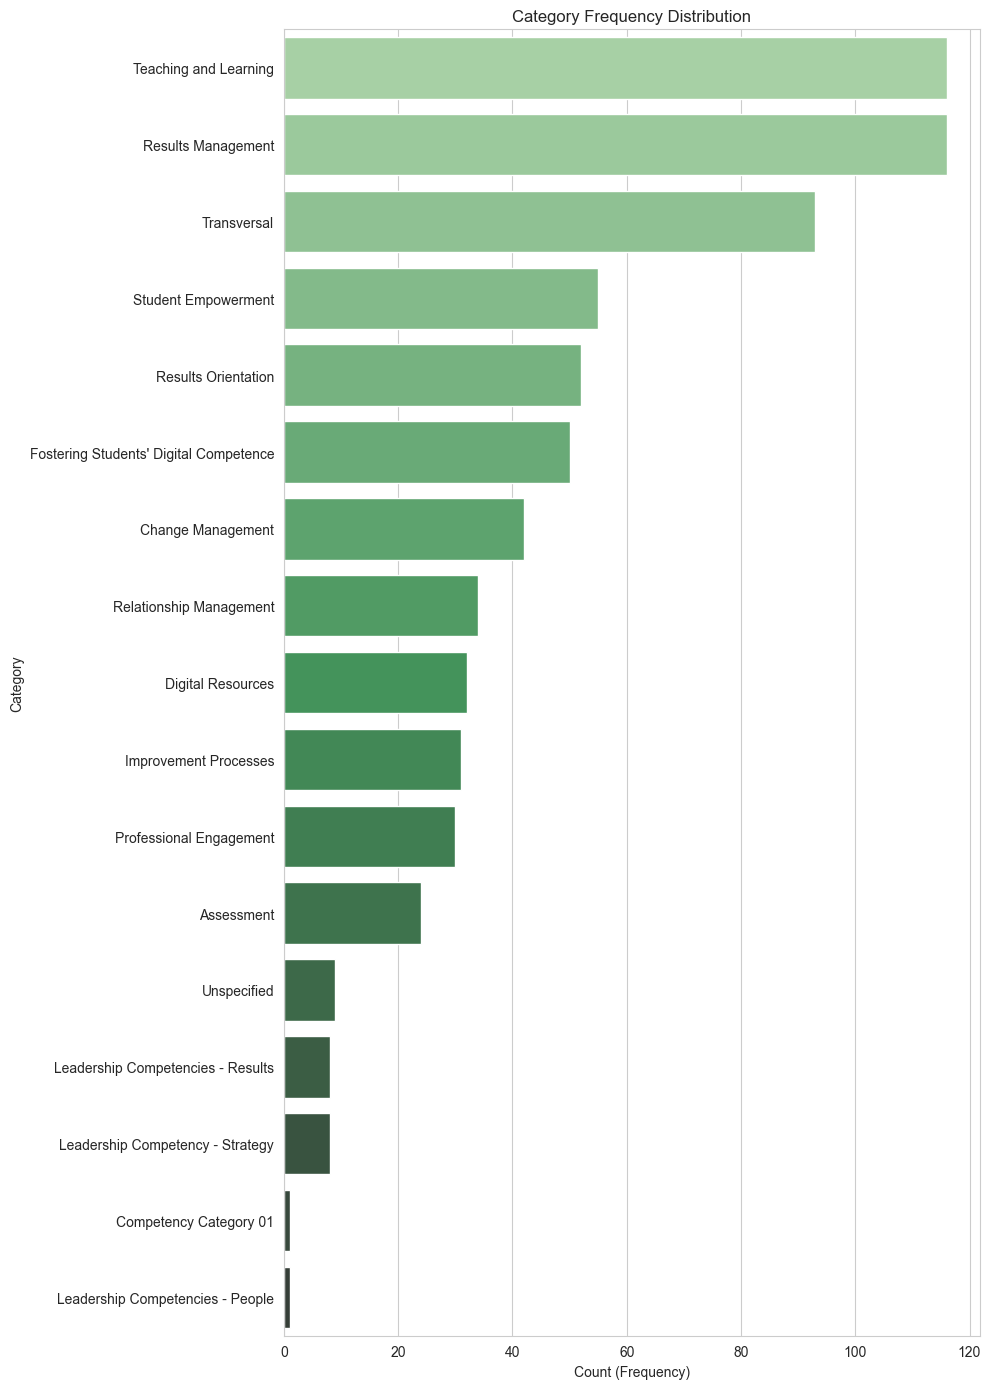

/var/folders/cm/fprgv9bn63x02h8m7ktf5_840000gn/T/ipykernel_14208/3997758630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


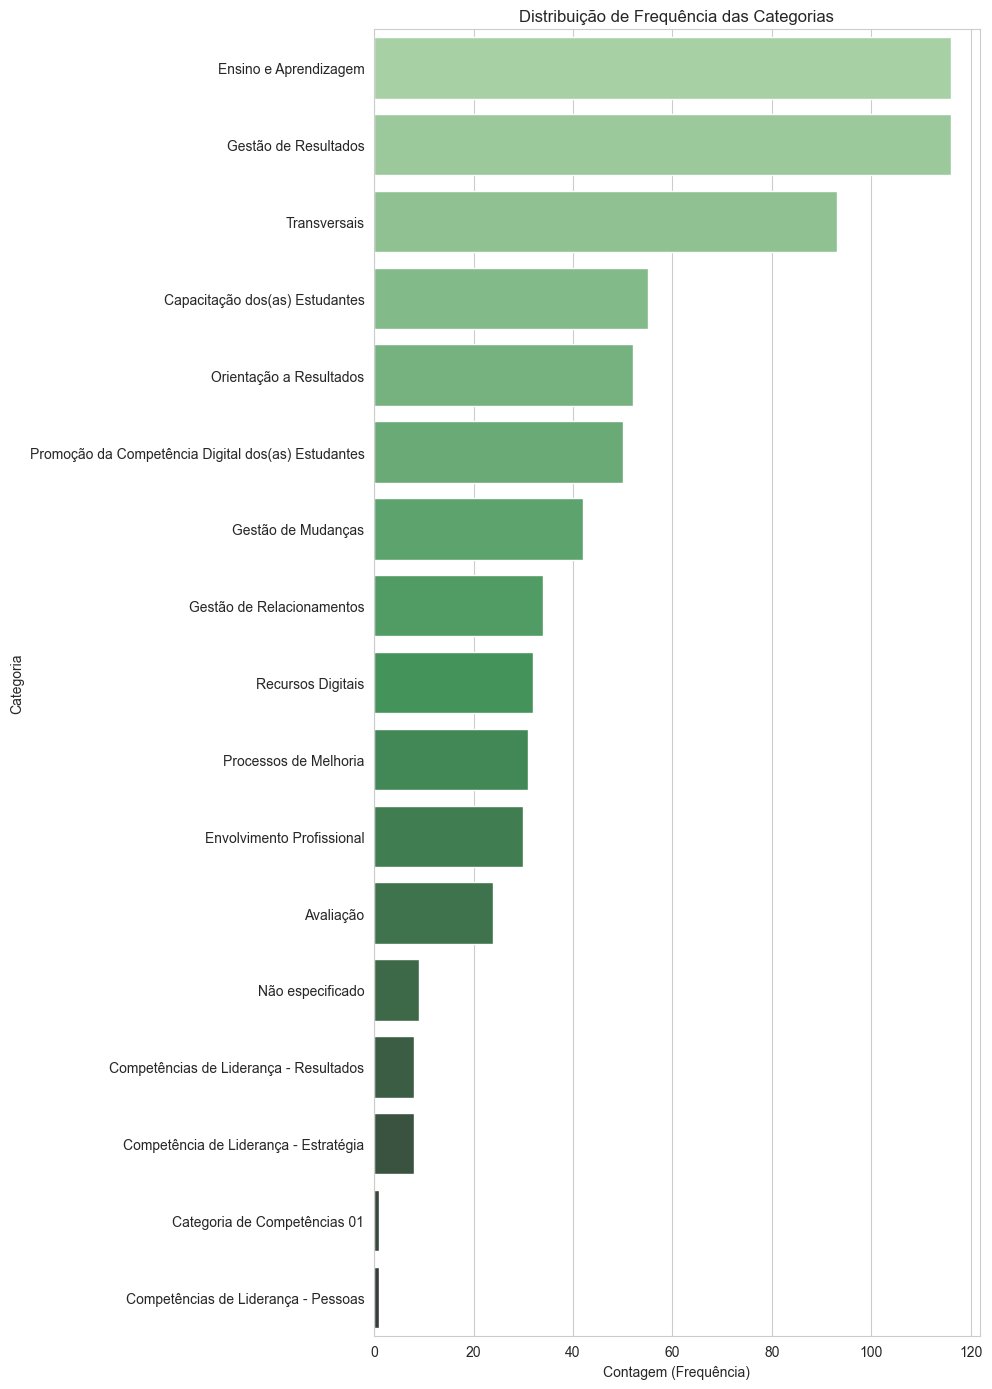

In [84]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 14))
sns.barplot(
    data=df_categories_freq,
    x="frequency",
    y="category_en",
    palette="Greens_d"
)
plt.title("Category Frequency Distribution")
plt.xlabel("Count (Frequency)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 14))
sns.barplot(
    data=df_categories_freq,
    x="frequency",
    y="cat_name",
    palette="Greens_d"
)
plt.title("Distribuição de Frequência das Categorias")
plt.xlabel("Contagem (Frequência)")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


## Course-Level Counts

The final sections evaluate how many unique competencies and categories each course contains.
Both distributions are shown with a histogram and a boxplot to highlight spread and central tendency.


In [85]:
competency_counts = (
    course_competencies.groupby("courseId")["comp_id"]
    .nunique()
    .reset_index(name="num_competencies")
)

competency_counts.head()


,courseId,num_competencies
0,02a304e6-2aed-4acf-852e-7668cac5df0e,2
1,03054354-9b05-4be5-bf8d-cd79bbf247ec,1
2,040cb677-7c58-4053-a00b-8dd16d772c5e,2
3,041220d0-21c3-4f7b-8e27-ca87b810f2f0,2
4,047772f6-5452-4924-abe6-1e9a2ed22e47,1


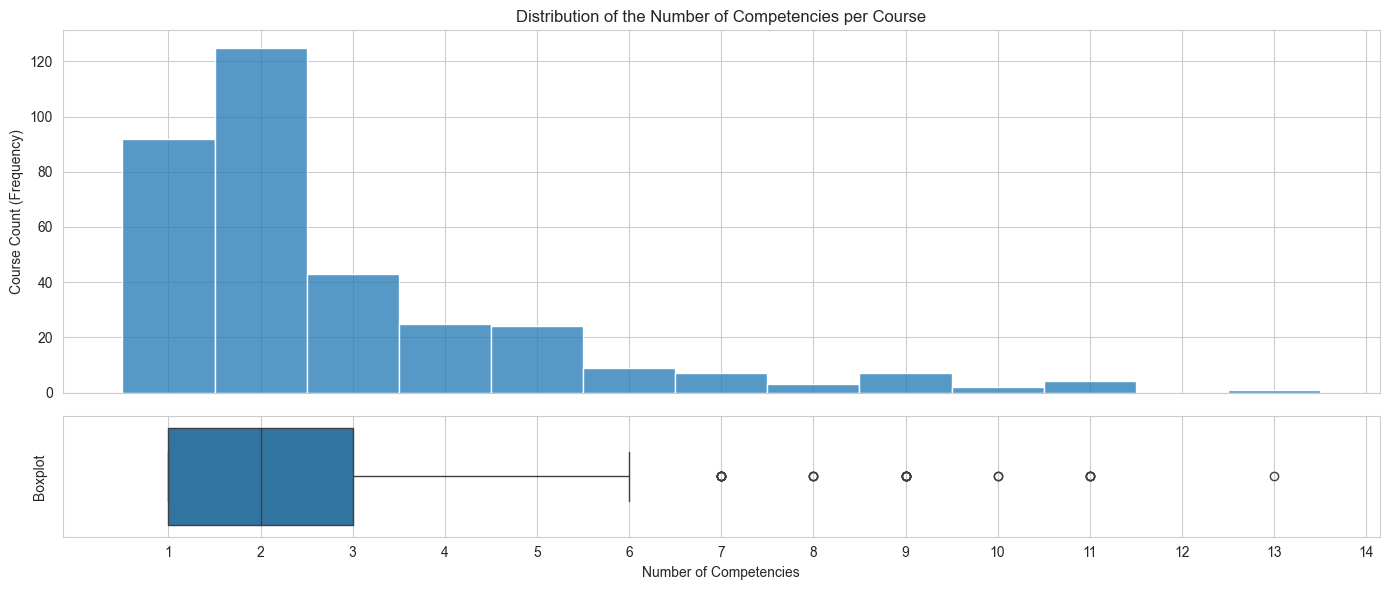

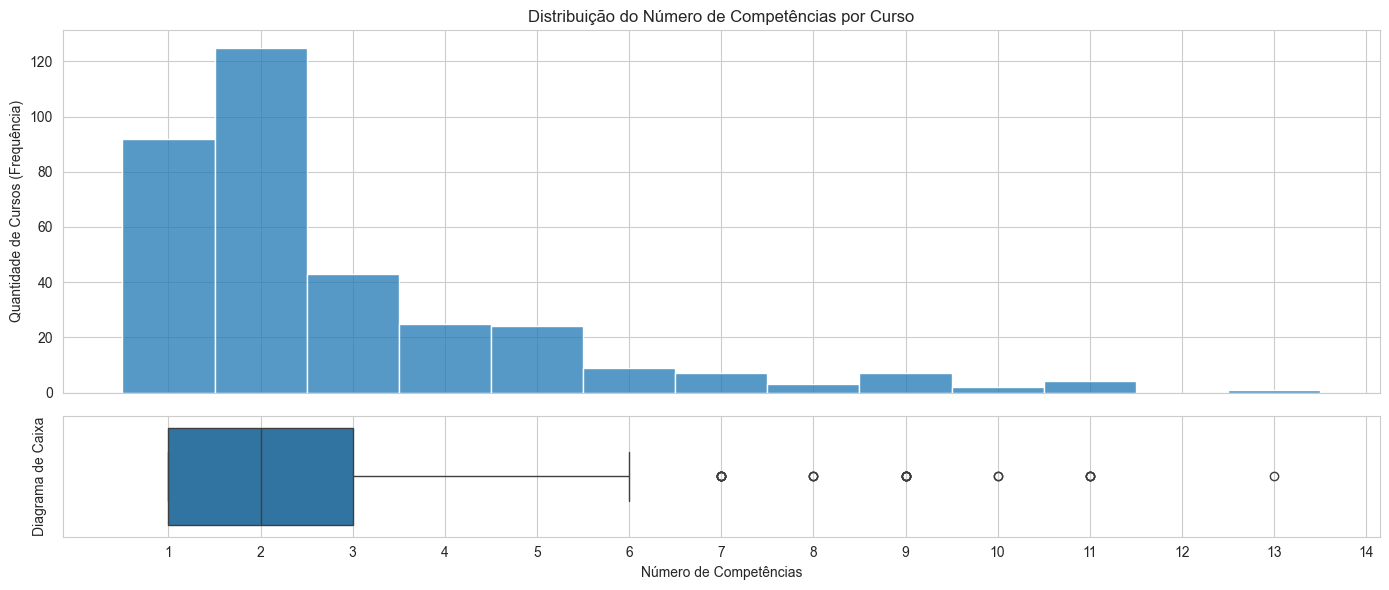

In [86]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(
    competency_counts["num_competencies"],
    ax=axes[0],
    binwidth=1,
    discrete=True
)

axes[0].set_title("Distribution of the Number of Competencies per Course")
axes[0].set_ylabel("Course Count (Frequency)")
axes[0].set_xlabel("")

sns.boxplot(
    x=competency_counts["num_competencies"],
    ax=axes[1]
)

axes[1].set_xlabel("Number of Competencies")
axes[1].set_ylabel("Boxplot")

max_comp = int(competency_counts["num_competencies"].max())
min_comp = int(competency_counts["num_competencies"].min())
axes[1].set_xticks(range(min_comp, max_comp + 2))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(
    competency_counts["num_competencies"],
    ax=axes[0],
    binwidth=1,
    discrete=True
)

axes[0].set_title("Distribuição do Número de Competências por Curso")
axes[0].set_ylabel("Quantidade de Cursos (Frequência)")
axes[0].set_xlabel("")

sns.boxplot(
    x=competency_counts["num_competencies"],
    ax=axes[1]
)

axes[1].set_xlabel("Número de Competências")
axes[1].set_ylabel("Diagrama de Caixa")
axes[1].set_xticks(range(min_comp, max_comp + 2))

plt.tight_layout()
plt.show()


In [87]:
category_counts = (
    course_categories.groupby("courseId")["cat_id"]
    .nunique()
    .reset_index(name="num_categories")
)

category_counts.head()


,courseId,num_categories
0,02a304e6-2aed-4acf-852e-7668cac5df0e,1
1,03054354-9b05-4be5-bf8d-cd79bbf247ec,1
2,040cb677-7c58-4053-a00b-8dd16d772c5e,1
3,041220d0-21c3-4f7b-8e27-ca87b810f2f0,1
4,047772f6-5452-4924-abe6-1e9a2ed22e47,1


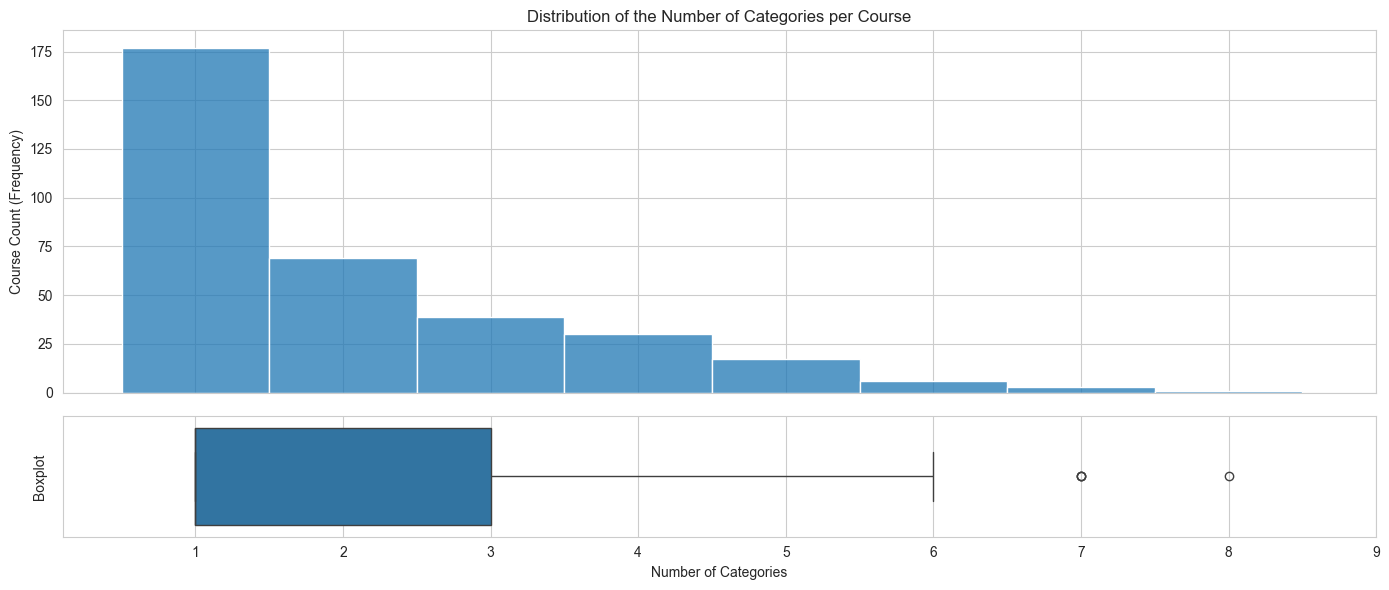

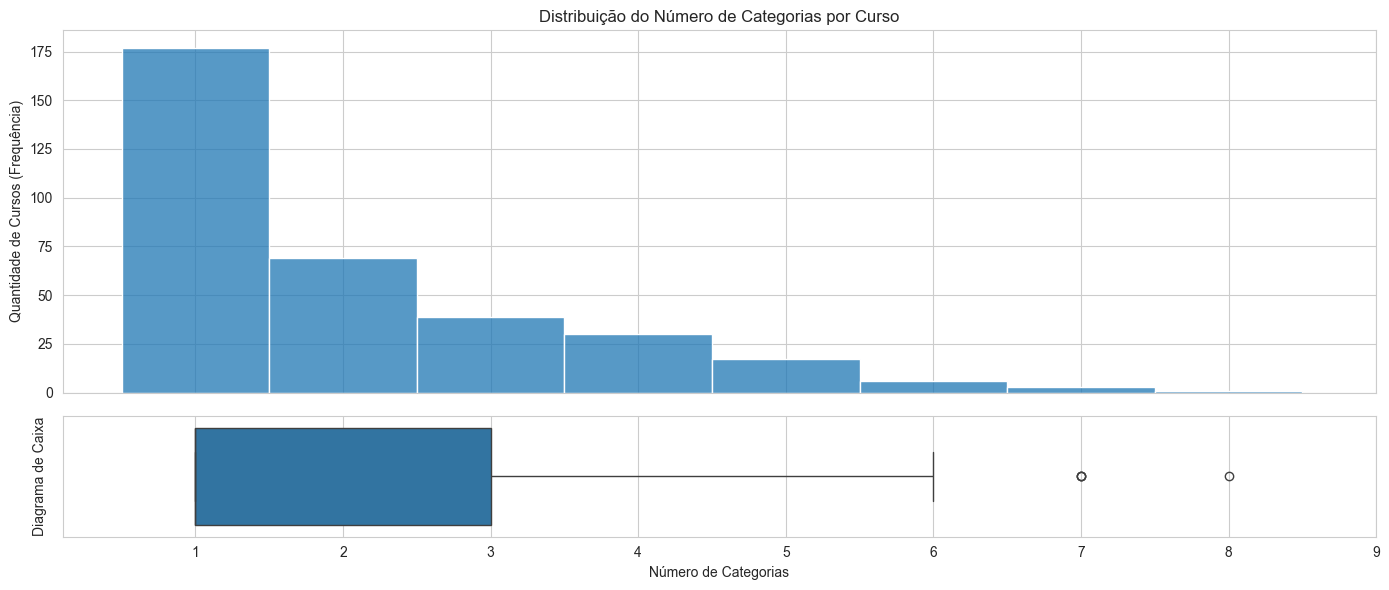

In [88]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(
    category_counts["num_categories"],
    ax=axes[0],
    binwidth=1,
    discrete=True
)

axes[0].set_title("Distribution of the Number of Categories per Course")
axes[0].set_ylabel("Course Count (Frequency)")
axes[0].set_xlabel("")

sns.boxplot(
    x=category_counts["num_categories"],
    ax=axes[1]
)

axes[1].set_xlabel("Number of Categories")
axes[1].set_ylabel("Boxplot")

max_cat = int(category_counts["num_categories"].max())
min_cat = int(category_counts["num_categories"].min())
axes[1].set_xticks(range(min_cat, max_cat + 2))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(
    category_counts["num_categories"],
    ax=axes[0],
    binwidth=1,
    discrete=True
)

axes[0].set_title("Distribuição do Número de Categorias por Curso")
axes[0].set_ylabel("Quantidade de Cursos (Frequência)")
axes[0].set_xlabel("")

sns.boxplot(
    x=category_counts["num_categories"],
    ax=axes[1]
)

axes[1].set_xlabel("Número de Categorias")
axes[1].set_ylabel("Diagrama de Caixa")
axes[1].set_xticks(range(min_cat, max_cat + 2))

plt.tight_layout()
plt.show()


In [89]:
category_counts["num_categories"].median()


np.float64(1.0)